In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from sklearn.ensemble import BaggingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

from sklearn.model_selection import GridSearchCV

In [5]:
df = pd.read_csv(r'D:\HIMANSHU\Desktop\RD\UDEMY CODE\Cancer Prediction\data\cancer_dataset.csv')
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


### Performing EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   int64  
 1   Gender            1500 non-null   int64  
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   int64  
 4   GeneticRisk       1500 non-null   int64  
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   int64  
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.6 KB


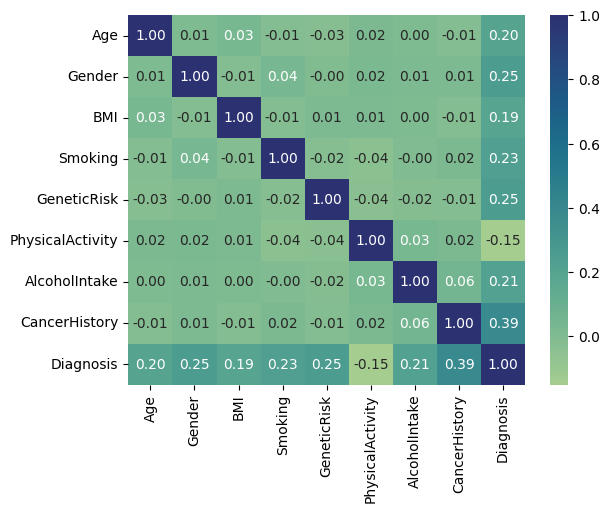

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000


In [7]:
df.shape

df.info()

df_corr = df.corr(numeric_only=True)
sns.heatmap(df_corr, cmap="crest", annot=True, fmt='.2f')
plt.show()

df['Diagnosis'].value_counts(normalize=True)*100
# 62.86 % - 0 ; 37.14 % - 1

df.isnull().sum()

df.duplicated()

df.describe()



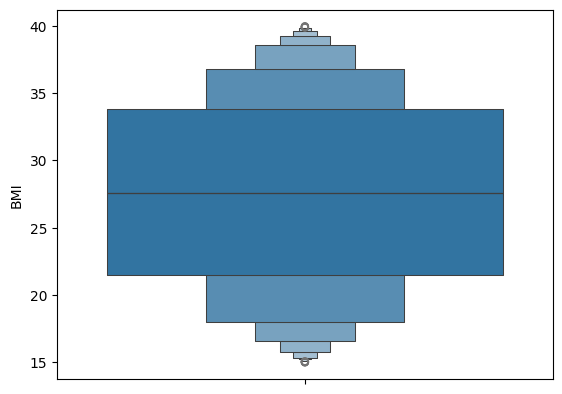

In [5]:
## Box Plot
sns.boxenplot(df['BMI'])
plt.show()

In [6]:
## Pair Plots
# sns.pairplot(df, hue='Diagnosis')
# plt.show()

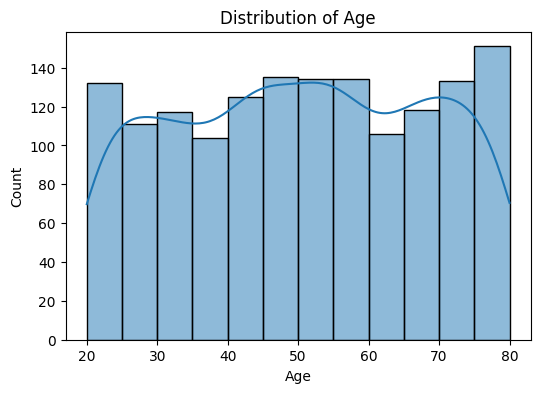

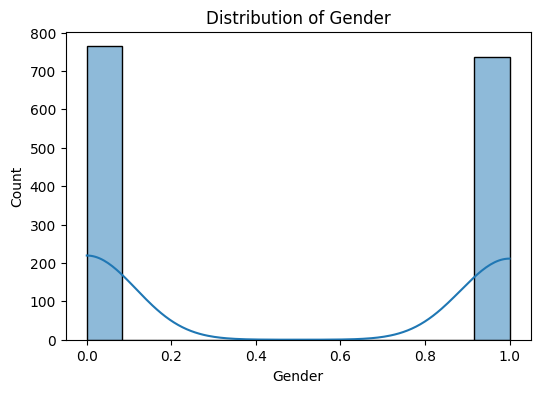

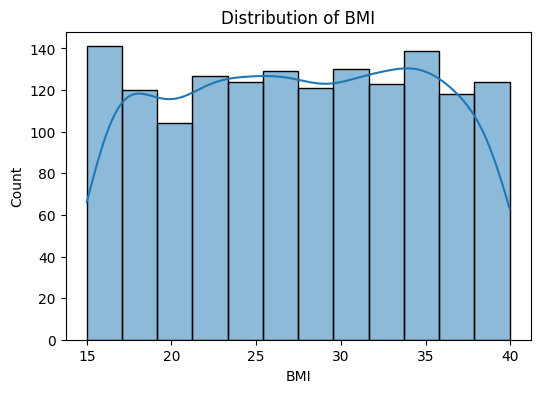

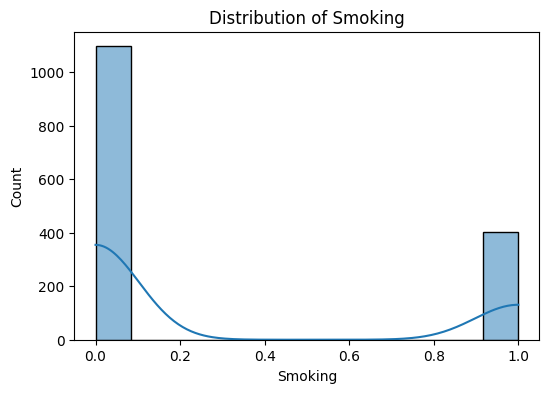

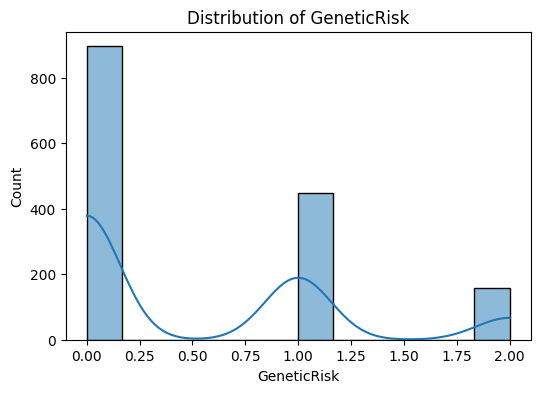

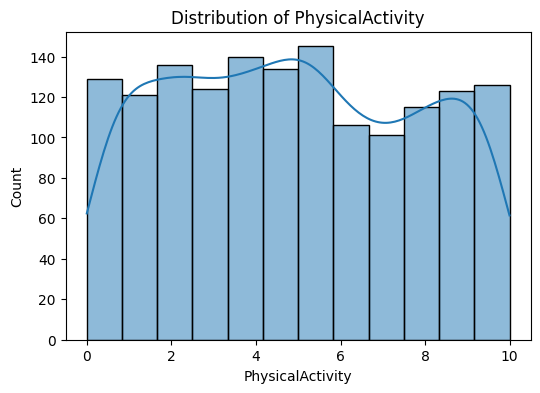

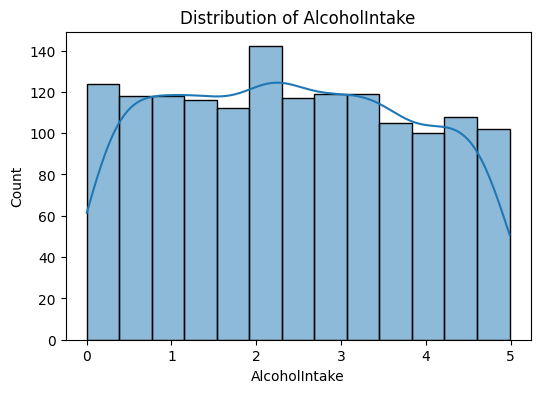

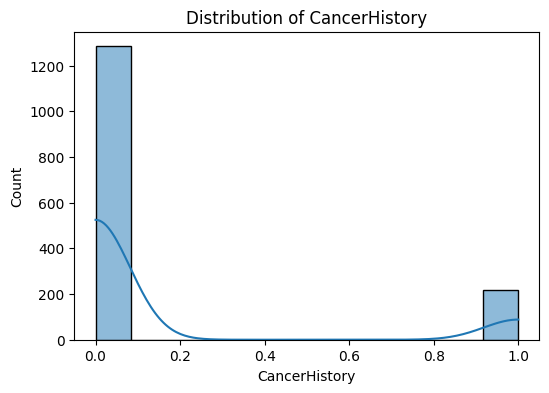

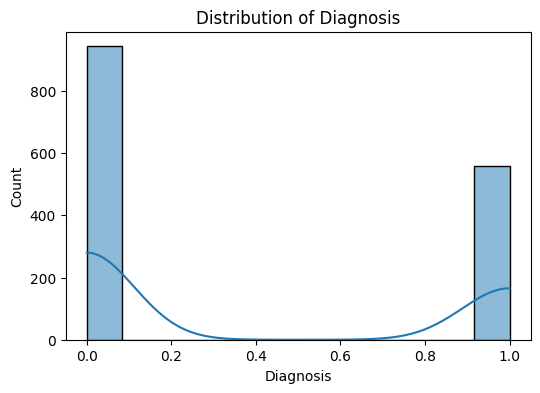

In [7]:
##  Descriptive Analysis (Hist Plot with KDE)
for i in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i], kde=True)
    plt.title(f"Distribution of {i}")
    plt.show()

### Defining Variables & Splitting Dataset & Standardization

In [8]:
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

## Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train)
len(X_test)

## Standardization
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

### Model Results (with Imabalanced Data)

In [9]:
## LogisticRegression
lr = LogisticRegression().fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

## Evalutaion
print(f"\nLogistic Regression Accuracy : {accuracy_score(y_pred_lr, y_test)*100}\n")
print(f"\n{classification_report(y_pred_lr, y_test)}\n")


Logistic Regression Accuracy : 86.33333333333333


              precision    recall  f1-score   support

           0       0.93      0.86      0.89       199
           1       0.76      0.87      0.81       101

    accuracy                           0.86       300
   macro avg       0.84      0.87      0.85       300
weighted avg       0.87      0.86      0.87       300




In [10]:
## DecisionTreeClassifier
dt = DecisionTreeClassifier().fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

## Evalutaion
print(f"\nDecision Tree Accuracy : {accuracy_score(y_pred_dt, y_test)*100}\n")
print(f"\n{classification_report(y_pred_dt, y_test)}\n")


Decision Tree Accuracy : 88.33333333333333


              precision    recall  f1-score   support

           0       0.92      0.89      0.91       191
           1       0.82      0.87      0.84       109

    accuracy                           0.88       300
   macro avg       0.87      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300




In [11]:
## RandomForestClassifier
rf = RandomForestClassifier().fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

## Evalutaion
print(f"\nRandom Forest Accuracy : {accuracy_score(y_pred_rf, y_test)*100}\n")
print(f"\n{classification_report(y_pred_rf, y_test)}\n")


Random Forest Accuracy : 92.66666666666666


              precision    recall  f1-score   support

           0       0.96      0.93      0.94       190
           1       0.88      0.93      0.90       110

    accuracy                           0.93       300
   macro avg       0.92      0.93      0.92       300
weighted avg       0.93      0.93      0.93       300




In [12]:
## BernoulliNB
nb = BernoulliNB().fit(X_train_sc, y_train)
y_pred_nb = nb.predict(X_test_sc)

## Evalutaion
print(f"\nNaive Bayes Accuracy : {accuracy_score(y_pred_nb, y_test)*100}\n")
print(f"\n{classification_report(y_pred_nb, y_test)}\n")


Naive Bayes Accuracy : 86.0


              precision    recall  f1-score   support

           0       0.96      0.83      0.89       212
           1       0.70      0.92      0.79        88

    accuracy                           0.86       300
   macro avg       0.83      0.88      0.84       300
weighted avg       0.88      0.86      0.86       300




In [13]:
## SVC
svm = SVC().fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)

## Evalutaion
print(f"\nSupport Vector Accuracy : {accuracy_score(y_pred_svm, y_test)*100}\n")
print(f"\n{classification_report(y_pred_svm, y_test)}\n")


Support Vector Accuracy : 89.0


              precision    recall  f1-score   support

           0       0.95      0.88      0.91       199
           1       0.79      0.91      0.85       101

    accuracy                           0.89       300
   macro avg       0.87      0.90      0.88       300
weighted avg       0.90      0.89      0.89       300




In [14]:
## KNeighborsClassifier
knn = KNeighborsClassifier().fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

## Evalutaion
print(f"\nK Neighbors Accuracy : {accuracy_score(y_pred_knn, y_test)*100}\n")
print(f"\n{classification_report(y_pred_knn, y_test)}\n")


K Neighbors Accuracy : 90.0


              precision    recall  f1-score   support

           0       0.94      0.90      0.92       192
           1       0.84      0.90      0.87       108

    accuracy                           0.90       300
   macro avg       0.89      0.90      0.89       300
weighted avg       0.90      0.90      0.90       300




In [15]:
## GradientBoostingClassifier
gb = GradientBoostingClassifier().fit(X_train_sc, y_train)
y_pred_gb = gb.predict(X_test_sc)

## Evalutaion
print(f"\nGradient Boosting Accuracy : {accuracy_score(y_pred_gb, y_test)*100}\n")
print(f"\n{classification_report(y_pred_gb, y_test)}\n")


Gradient Boosting Accuracy : 93.33333333333333


              precision    recall  f1-score   support

           0       0.96      0.93      0.95       190
           1       0.89      0.94      0.91       110

    accuracy                           0.93       300
   macro avg       0.92      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300




In [16]:
## AdaBoostClassifier
ada = AdaBoostClassifier().fit(X_train_sc, y_train)
y_pred_ada = ada.predict(X_test_sc)

## Evalutaion
print(f"\nAda Boost Accuracy : {accuracy_score(y_pred_ada, y_test)*100}\n")
print(f"\n{classification_report(y_pred_ada, y_test)}\n")


Ada Boost Accuracy : 94.66666666666667


              precision    recall  f1-score   support

           0       0.99      0.93      0.96       196
           1       0.88      0.98      0.93       104

    accuracy                           0.95       300
   macro avg       0.93      0.95      0.94       300
weighted avg       0.95      0.95      0.95       300




In [17]:
## xgb
xgb_clf = xgb.XGBClassifier()
xgb_clf.fit(X_train_sc, y_train)
y_pred_xgb_clf = xgb_clf.predict(X_test_sc)

## Evalutaion
print(f"\nXG Boost Accuracy : {accuracy_score(y_pred_xgb_clf, y_test)*100}\n")
print(f"\n{classification_report(y_pred_xgb_clf, y_test)}\n")


XG Boost Accuracy : 92.33333333333333


              precision    recall  f1-score   support

           0       0.96      0.92      0.94       191
           1       0.87      0.93      0.90       109

    accuracy                           0.92       300
   macro avg       0.91      0.92      0.92       300
weighted avg       0.93      0.92      0.92       300




In [18]:
## BaggingClassifier
bag = BaggingClassifier().fit(X_train_sc, y_train)
y_pred_bag = bag.predict(X_test_sc)

## Evalutaion
print(f"\nBagging Accuracy : {accuracy_score(y_pred_bag, y_test)*100}\n")
print(f"\n{classification_report(y_pred_bag, y_test)}\n")


Bagging Accuracy : 90.66666666666666


              precision    recall  f1-score   support

           0       0.94      0.91      0.93       190
           1       0.85      0.90      0.88       110

    accuracy                           0.91       300
   macro avg       0.90      0.91      0.90       300
weighted avg       0.91      0.91      0.91       300




In [19]:
## LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis().fit(X_train_sc, y_train)
y_pred_lda = lda.predict(X_test_sc)

## Evalutaion
print(f"\nLDA Accuracy : {accuracy_score(y_pred_lda, y_test)*100}\n")
print(f"\n{classification_report(y_pred_lda, y_test)}\n")


LDA Accuracy : 86.0


              precision    recall  f1-score   support

           0       0.93      0.85      0.89       200
           1       0.75      0.87      0.81       100

    accuracy                           0.86       300
   macro avg       0.84      0.86      0.85       300
weighted avg       0.87      0.86      0.86       300




In [20]:
## QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis().fit(X_train_sc, y_train)
y_pred_qda = qda.predict(X_test_sc)

## Evalutaion
print(f"\nQDA Accuracy : {accuracy_score(y_pred_qda, y_test)*100}\n")
print(f"\n{classification_report(y_pred_qda, y_test)}\n")


QDA Accuracy : 85.33333333333334


              precision    recall  f1-score   support

           0       0.92      0.85      0.89       200
           1       0.74      0.86      0.80       100

    accuracy                           0.85       300
   macro avg       0.83      0.85      0.84       300
weighted avg       0.86      0.85      0.86       300




| Model | Accuracy | Precision | Recall | F1 Score |
| --- | --- | --- | --- | --- |
| Logistic R. | 86.34 | 0.76 | 0.87 | 0.81 | 
| Decision Tree | 87.67 | 0.81 | 0.86 | 0.84 | 
| Random Forest | 92.00 | 0.87 | 0.92 | 0.89 | 
| Naive Bayes | 86.00 | 0.70 | 0.92 | 0.79 | 
| Support Vector M. | 89.00 | 0.79 | 0.91 | 0.85 | 
| K Nearest N. | 90.00 | 0.84 | 0.90 | 0.87 | 
| Gradient Boost | 93.34 | 0.89 | 0.94 | 0.91 | 
| ADA Boost | 94.67 | 0.88 | 0.98 | 0.93 | 
| XG Boost | 92.34 | 0.87 | 0.93 | 0.90 | 
| Bagging | 92.00 | 0.85 | 0.93 | 0.89 | 
| LDA | 86.00 | 0.75 | 0.87 | 0.81 | 
| QDA | 85.34 | 0.74 | 0.86 | 0.80 |


### Model Results (with Balanced Data) - SMOTE

In [21]:
## SMOTE
smo = SMOTE(random_state=42)
Xsmo, ysmo = smo.fit_resample(X, y)

## Splitting Dataset
Xsmo_train, Xsmo_test, ysmo_train, ysmo_test = train_test_split(Xsmo, ysmo, test_size=0.2, random_state=42)

## Standardization
Xsmo_train_sc = sc.fit_transform(Xsmo_train)
Xsmo_test_sc = sc.fit_transform(Xsmo_test)

In [22]:
## AdaBoostClassifier
ada_smo = AdaBoostClassifier(random_state=42).fit(Xsmo_train_sc, ysmo_train)
ysmo_pred_ada = ada_smo.predict(Xsmo_test_sc)

## Evalutaion
print(f"\nAda Boost ROS Accuracy : {accuracy_score(ysmo_pred_ada, ysmo_test)*100}\n")
print(f"\n{classification_report(ysmo_pred_ada, ysmo_test)}\n")


Ada Boost ROS Accuracy : 84.39153439153439


              precision    recall  f1-score   support

           0       0.85      0.84      0.84       189
           1       0.84      0.85      0.85       189

    accuracy                           0.84       378
   macro avg       0.84      0.84      0.84       378
weighted avg       0.84      0.84      0.84       378




In [23]:
## GradientBoostingClassifier
gbsmo = GradientBoostingClassifier(random_state=42).fit(Xsmo_train_sc, ysmo_train)
ysmo_pred_gb = gbsmo.predict(Xsmo_test_sc)

## Evalutaion
print(f"\nGradient Boosting Accuracy : {accuracy_score(ysmo_pred_gb, ysmo_test)*100}\n")
print(f"\n{classification_report(ysmo_pred_gb, ysmo_test)}\n")


Gradient Boosting Accuracy : 84.65608465608466


              precision    recall  f1-score   support

           0       0.88      0.82      0.85       198
           1       0.82      0.87      0.84       180

    accuracy                           0.85       378
   macro avg       0.85      0.85      0.85       378
weighted avg       0.85      0.85      0.85       378




In [24]:
## xgb
xgbsmo = xgb.XGBClassifier(random_state=42).fit(Xsmo_train_sc, ysmo_train)
ysmo_pred_xgb = xgbsmo.predict(Xsmo_test_sc)

## Evalutaion
print(f"\nXG Boost Accuracy : {accuracy_score(ysmo_pred_xgb, ysmo_test)*100}\n")
print(f"\n{classification_report(ysmo_pred_xgb, ysmo_test)}\n")


XG Boost Accuracy : 76.71957671957672


              precision    recall  f1-score   support

           0       0.87      0.72      0.79       224
           1       0.67      0.84      0.75       154

    accuracy                           0.77       378
   macro avg       0.77      0.78      0.77       378
weighted avg       0.79      0.77      0.77       378




---> SMOTE

| Model | Accuracy | Precision | Recall | F1 Score |
| --- | --- | --- | --- | --- |
| Ada Boost SMOTE | 84.39 | 0.85 | 0.84 | 0.85 | 
| Decision Tree SMOTE | 84.65 | 0.83 | 0.89 | 0.86 | 
| Random Forest SMOTE | 76.71 | 0.68 | 0.88 | 0.77 | 

### Model Results (with Balanced Data) - RandomOverSampler

In [25]:
## RandomOverSampler
ros = RandomOverSampler(random_state=42)
Xros , yros = ros.fit_resample(X, y)

## Splitting Dataset
Xros_train, Xros_test, yros_train, yros_test = train_test_split(Xros, yros, test_size=0.2, random_state=42)

## Standardization
Xros_train_sc = sc.fit_transform(Xros_train)
Xros_test_sc = sc.fit_transform(Xros_test)

In [26]:
## AdaBoostClassifier
ada_ros = AdaBoostClassifier(random_state=42).fit(Xros_train_sc, yros_train)
yros_pred_ada = ada_ros.predict(Xros_test_sc)

## Evalutaion
print(f"\nAda Boost ROS Accuracy : {accuracy_score(yros_pred_ada, yros_test)*100}\n")
print(f"\n{classification_report(yros_pred_ada, yros_test)}\n")


Ada Boost ROS Accuracy : 96.29629629629629


              precision    recall  f1-score   support

           0       0.97      0.95      0.96       190
           1       0.95      0.97      0.96       188

    accuracy                           0.96       378
   macro avg       0.96      0.96      0.96       378
weighted avg       0.96      0.96      0.96       378




In [27]:
## GradientBoostingClassifier
gbros = GradientBoostingClassifier(random_state=42).fit(Xros_train_sc, yros_train)
yros_pred_gb = gbros.predict(Xros_test_sc)

## Evalutaion
print(f"\nGradient Boosting Accuracy : {accuracy_score(yros_pred_gb, yros_test)*100}\n")
print(f"\n{classification_report(yros_pred_gb, yros_test)}\n")


Gradient Boosting Accuracy : 94.17989417989418


              precision    recall  f1-score   support

           0       0.94      0.94      0.94       186
           1       0.94      0.94      0.94       192

    accuracy                           0.94       378
   macro avg       0.94      0.94      0.94       378
weighted avg       0.94      0.94      0.94       378




In [28]:
## xgb
xgbros = xgb.XGBClassifier(random_state=42).fit(Xros_train_sc, yros_train)
yros_pred_xgb = xgbros.predict(Xros_test_sc)

## Evalutaion
print(f"\nXG Boost Accuracy : {accuracy_score(yros_pred_xgb, yros_test)*100}\n")
print(f"\n{classification_report(yros_pred_xgb, yros_test)}\n")


XG Boost Accuracy : 82.53968253968253


              precision    recall  f1-score   support

           0       0.95      0.76      0.84       232
           1       0.71      0.93      0.80       146

    accuracy                           0.83       378
   macro avg       0.83      0.85      0.82       378
weighted avg       0.85      0.83      0.83       378




---> Random Over Sampler

| Model | Accuracy | Precision | Recall | F1 Score |
| --- | --- | --- | --- | --- |
| Ada Boost ROS | 96.29 | 0.95 | 0.97 | 0.96 | 
| Decision Tree ROS | 94.10 | 0.94 | 0.94 | 0.94 | 
| Random Forest ROS | 82.53 | 0.71 | 0.93 | 0.80 | 

### Model Results (with Balanced Data) - ADASYN

In [29]:
## ADASYN
adasyn = ADASYN(random_state=42)
Xadasyn , yadasyn = adasyn.fit_resample(X, y)

## Splitting Dataset
Xadasyn_train, Xadasyn_test, yadasyn_train, yadasyn_test = train_test_split(Xadasyn, yadasyn, test_size=0.2, random_state=42)

## Standardization
Xadasyn_train_sc = sc.fit_transform(Xadasyn_train)
Xadasyn_test_sc = sc.fit_transform(Xadasyn_test)

In [30]:
## AdaBoostClassifier
ada_adasyn = AdaBoostClassifier(random_state=42).fit(Xadasyn_train_sc, yadasyn_train)
yadasyn_pred_ada = ada_adasyn.predict(Xadasyn_test_sc)

## Evalutaion
print(f"\nAda Boost ROS Accuracy : {accuracy_score(yadasyn_pred_ada, yadasyn_test)*100}\n")
print(f"\n{classification_report(yadasyn_pred_ada, yadasyn_test)}\n")


Ada Boost ROS Accuracy : 81.49100257069408


              precision    recall  f1-score   support

           0       0.77      0.83      0.80       175
           1       0.85      0.80      0.83       214

    accuracy                           0.81       389
   macro avg       0.81      0.82      0.81       389
weighted avg       0.82      0.81      0.82       389




In [31]:
## GradientBoostingClassifier
gbadasyn = GradientBoostingClassifier(random_state=42).fit(Xadasyn_train_sc, yadasyn_train)
yadasyn_pred_gb = gbadasyn.predict(Xadasyn_test_sc)

## Evalutaion
print(f"\nGradient Boosting Accuracy : {accuracy_score(yadasyn_pred_gb, yadasyn_test)*100}\n")
print(f"\n{classification_report(yadasyn_pred_gb, yadasyn_test)}\n")


Gradient Boosting Accuracy : 78.9203084832905


              precision    recall  f1-score   support

           0       0.78      0.79      0.78       187
           1       0.80      0.79      0.80       202

    accuracy                           0.79       389
   macro avg       0.79      0.79      0.79       389
weighted avg       0.79      0.79      0.79       389




In [32]:
## xgb
xgbadasyn = xgb.XGBClassifier().fit(Xadasyn_train_sc, yadasyn_train)
yadasyn_pred_xgb = xgbadasyn.predict(Xadasyn_test_sc)

## Evalutaion
print(f"\nXG Boost Accuracy : {accuracy_score(yadasyn_pred_xgb, yadasyn_test)*100}\n")
print(f"\n{classification_report(yadasyn_pred_xgb, yadasyn_test)}\n")


XG Boost Accuracy : 76.34961439588689


              precision    recall  f1-score   support

           0       0.85      0.72      0.78       223
           1       0.69      0.83      0.75       166

    accuracy                           0.76       389
   macro avg       0.77      0.77      0.76       389
weighted avg       0.78      0.76      0.76       389




| Model | Accuracy | Precision | Recall | F1 Score |
| --- | --- | --- | --- | --- |
| Ada Boost ADASYN | 81.49 | 0.85 | 0.80 | 0.83 | 
| Decision Tree ADASYN | 78.92 | 0.80 | 0.79 | 0.80 | 
| Random Forest ADASYN | 76.34 | 0.69 | 0.83 | 0.75 | 

### Model Results ( ROS + GRID Search CV)

In [50]:
## AdaBoostClassifier
ada_ros = AdaBoostClassifier(random_state=42)

## Grid Search CV
parameters = {
    'n_estimators' : [50,100,150,200,250],
    'learning_rate' : [0.01, 0.05, 0.1, 0.5, 1],
}

grid_ada = GridSearchCV(ada_ros, param_grid=parameters, cv=5, scoring='f1')
grid_ada.fit(Xros_train_sc, yros_train)
best_ada = grid_ada.best_estimator_
yros_pred_ada = best_ada.predict(Xros_test_sc)

## Evalutaion
print(f"Best Patameters : {grid_ada.best_estimator_}")
print(f"\nAda Boost ROS Accuracy : {accuracy_score(yros_pred_ada, yros_test)*100}\n")
print(f"\n{classification_report(yros_pred_ada, yros_test)}\n")

Best Patameters : AdaBoostClassifier(learning_rate=0.5, n_estimators=150, random_state=42)

Ada Boost ROS Accuracy : 96.29629629629629


              precision    recall  f1-score   support

           0       0.97      0.96      0.96       188
           1       0.96      0.97      0.96       190

    accuracy                           0.96       378
   macro avg       0.96      0.96      0.96       378
weighted avg       0.96      0.96      0.96       378




In [ ]:
## GradientBoostingClassifier
gbros = GradientBoostingClassifier(random_state=42).fit(Xros_train_sc, yros_train)
yros_pred_gb = gbros.predict(Xros_test_sc)

## Grid Search CV
parameters = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_gb = GridSearchCV(gbros, param_grid=parameters, cv=5, scoring='f1')
grid_gb.fit(Xros_train_sc, yros_train)
best_gb = grid_gb.best_estimator_
yros_pred_gb = best_gb.predict(Xros_test_sc)

## Evalutaion
print(f"Best Patameters : {grid_gb.best_estimator_}")
print(f"\nGradient Boosting Accuracy : {accuracy_score(yros_pred_gb, yros_test)*100}\n")
print(f"\n{classification_report(yros_pred_gb, yros_test)}\n")

Best Patameters : GradientBoostingClassifier(max_depth=4, min_samples_split=5, n_estimators=200,
                           random_state=42)

Gradient Boosting Accuracy : 94.17989417989418


              precision    recall  f1-score   support

           0       0.94      0.94      0.94       186
           1       0.94      0.94      0.94       192

    accuracy                           0.94       378
   macro avg       0.94      0.94      0.94       378
weighted avg       0.94      0.94      0.94       378




In [48]:
## xgb
xgbros = xgb.XGBClassifier(random_state=42).fit(Xros_train_sc, yros_train)
yros_pred_xgb = xgbros.predict(Xros_test_sc)

## Grid Search CV
parameters = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgbros, param_grid=parameters, cv=5, scoring='f1')
grid_xgb.fit(Xros_train_sc, yros_train)
best_xgb = grid_xgb.best_estimator_
yros_pred_xgb = best_xgb.predict(Xros_test_sc)

## Evalutaion
print(f"Best Patameters : {grid_xgb.best_estimator_}")
print(f"\nXG Boost Accuracy : {accuracy_score(yros_pred_xgb, yros_test)*100}\n")
print(f"\n{classification_report(yros_pred_xgb, yros_test)}\n")

Best Patameters : XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

XG Boost Accuracy : 83.06878306878306


              precision    recall  f1-score   support

           0       0.95      0.77      0.85       230
           1       0.72      0.93      0.81       148

    accuracy          

---> Random Over Sampler + GRID Search CV

| Model | Accuracy | Precision | Recall | F1 Score |
| --- | --- | --- | --- | --- |
| Ada Boost ROS | 96.29 | 0.96 | 0.97 | 0.96 | 
| Decision Tree ROS | 94.17 | 0.94 | 0.94 | 0.94 | 
| Random Forest ROS | 83.06 | 0.72 | 0.93 | 0.81 | 